In [14]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, differential_evolution
import warnings
import matplotlib.pyplot as plt

In [2]:
#Load dataset
df = pd.read_csv('../data.csv')

In [4]:
df

,Serial. Number,Initial concentration of M.B. (Co) (mg/l),Final concentration of M.B. (Cf) (mg/l),Weight of adsorbent (GAC) (g),amount of adsorbed by adsorbent at equilibrium (qe) (mg/g)
0,1,2,0.061266,0.9,0.107707
1,2,6,0.211028,0.9,0.321610
2,3,10,0.510551,0.9,0.527192
3,4,14,0.837304,0.9,0.731261
4,5,18,1.307012,0.9,0.927388
5,6,22,1.715453,0.9,1.126919
6,7,26,2.246426,0.9,1.319643
7,8,30,2.940776,0.9,1.503290


In [5]:
#Extract data
xData = df['Final concentration of M.B. (Cf) (mg/l)'].values #Ce
yData = df['amount of adsorbed by adsorbent at equilibrium (qe) (mg/g)'].values 

In [6]:
#Fruendlich Model
def func(x, Kf, n):
    return Kf*(x**(1.0/n))

In [7]:
#Error function
def sum_of_squared_error(parameter_tuple):
    warnings.filterwarnings("ignore")
    val = func(xData, *parameter_tuple)
    return np.sum((yData - val) ** 2.0)

In [8]:
#Initial parameter estimation using generic algorithm
def generate_initial_parameters():
    min_x, max_x = min(xData), max(xData)
    min_y, max_y = min(yData), max(yData)

    parameter_bounds=[]
    parameter_bounds.append([0.001, max_y]) #Kf bounds
    parameter_bounds.append([0.1, 10]) #n bounds

    result = differential_evolution(sum_of_squared_error, parameter_bounds, seed=3)
    return result.x

In [9]:
#Generate initial parameters
genetic_parameters = generate_initial_parameters()

In [10]:
#Curve fitting
fitted_parameters, pcov = curve_fit(func, xData, yData, genetic_parameters)

Kf, n = fitted_parameters
print(f'Parameters (Kf, n)=({Kf}, {n})')

Parameters (Kf, n)=(0.7991018811330427, 1.6615012213853657)


In [11]:
#Predictions
model_predictions = func(xData, *fitted_parameters)

In [12]:
#Error Calculation
absolute_error = abs(model_predictions - yData)
squared_error = np.square(absolute_error)
mse = np.mean(squared_error)
rmse = np.sqrt(mse)
n=len(yData)
p=2 #no. of parameters

hybrid = (100.0/(n-p)) * np.sum(squared_error/yData)
mpsd = 100.0*np.sqrt((1.0/(n-p)) * np.sum(np.square(absolute_error/yData)))
chi_square = np.sum(squared_error/yData)

In [13]:
#Output results
print('ERRSQ:      ', np.sum(squared_error))
print('RMSE:       ', rmse)
print('HYBRID:     ', hybrid)
print('EABS:       ', np.sum(absolute_error))
print('MPSD:       ', mpsd)
print('Chi-square: ', chi_square)

ERRSQ:       0.003596018671971559
RMSE:        0.021201470090454692
HYBRID:      0.2914212193602555
EABS:        0.1464130248014187
MPSD:        15.698462615850342
Chi-square:  0.017485273161615328


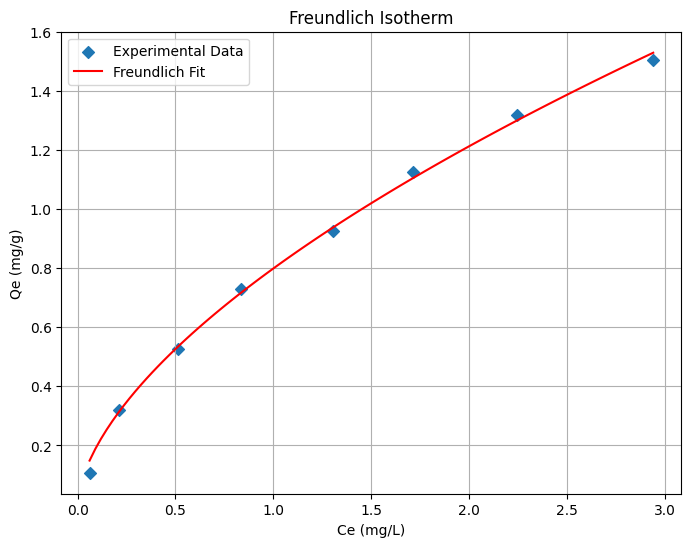

In [15]:
#Plotting
def plot():
    plt.figure(figsize=(8,6))

    #Scatter plot
    plt.scatter(xData, yData, marker='D', label='Experimental Data')

    #Model Curve
    xModel = np.linspace(min(xData), max(xData), 100)
    yModel = func(xModel, *fitted_parameters)

    plt.plot(xModel, yModel,color='red', label='Freundlich Fit')

    plt.title('Freundlich Isotherm')
    plt.xlabel('Ce (mg/L)')
    plt.ylabel('Qe (mg/g)')
    plt.legend()
    plt.grid()

    plt.show()

plot()